MOBILE PRICE CLASSIFICATION PROJECT

1. INSTALL LIBRARIES

In [1]:
!pip install pandas scikit-learn matplotlib seaborn

2. IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

3. MOUNT GOOGLE DRIVE

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


4. LOAD DATASET FROM DRIVE

In [7]:
data_path = "/content/drive/MyDrive/ML_Dataset/mobile_price_dataset.csv"
data = pd.read_csv(data_path)

5. DATA UNDERSTANDING

In [8]:
print("\n===== DATA INFORMATION =====")
print("Shape of dataset:", data.shape)
print("\nColumns:\n", data.columns)
print("\n===== FIRST 5 ROWS =====")
print(data.head())

print("\n===== LAST 5 ROWS =====")
print(data.tail())



===== DATA INFORMATION =====
Shape of dataset: (891, 12)

Columns:
 Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

===== FIRST 5 ROWS =====
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/

6. DATA TYPES & MISSING VALUES





In [9]:
print("\n===== DATA TYPES =====")
print(data.dtypes)

print("\n===== MISSING VALUES =====")
print(data.isnull().sum())


===== DATA TYPES =====
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

===== MISSING VALUES =====
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


7. STATISTICAL SUMMARY

In [10]:
print("\n===== STATISTICAL SUMMARY =====")
print(data.describe())


===== STATISTICAL SUMMARY =====
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


 8. DATA VISUALIZATION - HEATMAP


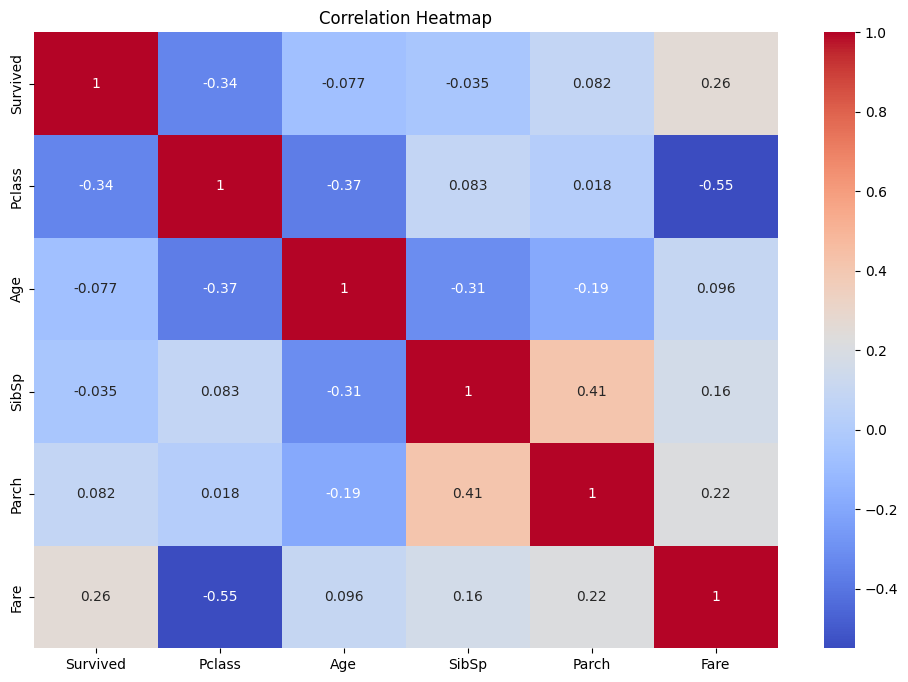

In [12]:
plt.figure(figsize=(12,8))
# Drop non-numeric and identifier columns for correlation calculation
numeric_data = data.drop(columns=['PassengerId', 'Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'])
sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

 9. DISTRIBUTION PLOTS

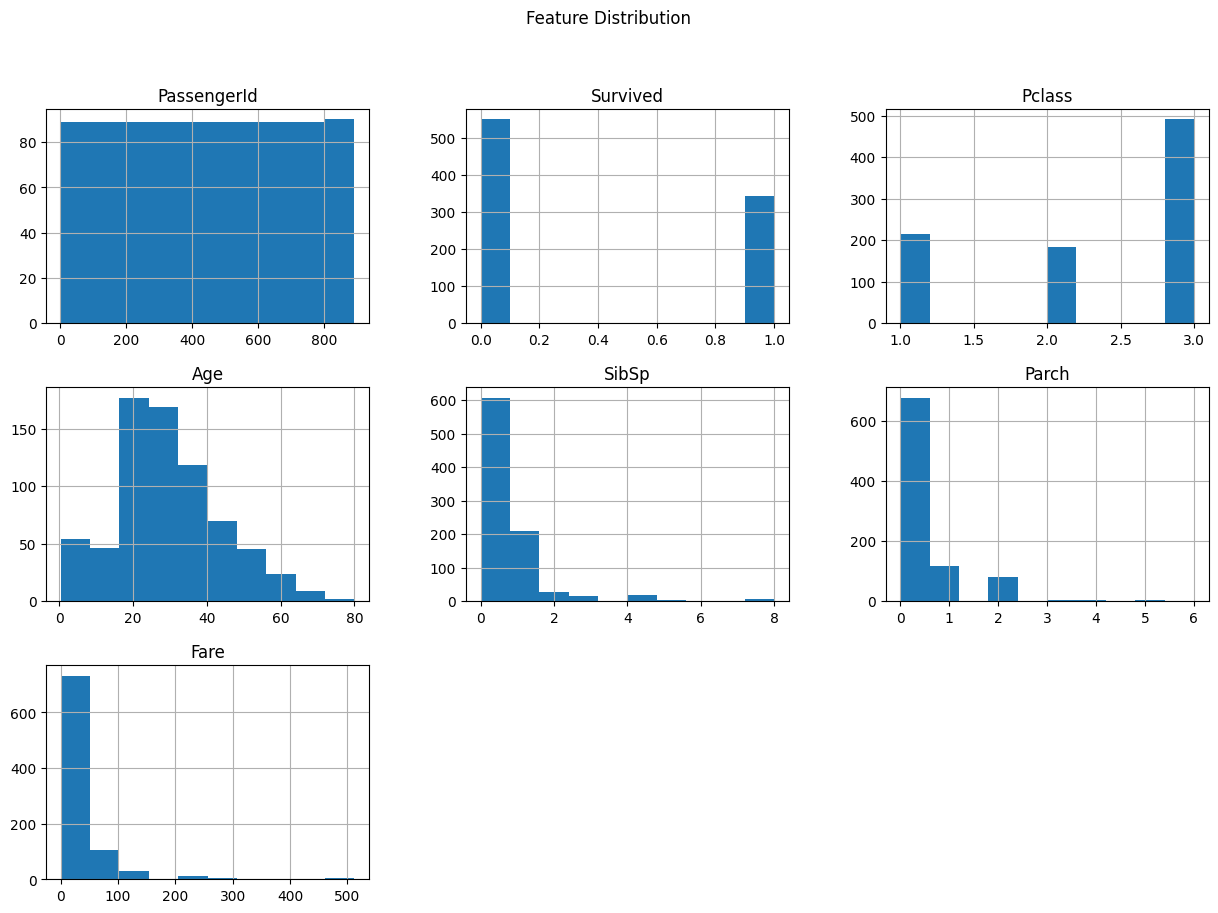

In [13]:
data.hist(figsize=(15,10))
plt.suptitle("Feature Distribution")
plt.show()

10. FEATURE & TARGET

In [15]:
X = data.drop("Survived", axis=1)
y = data["Survived"]

print("\n===== FEATURES =====")
print(X.columns)


===== FEATURES =====
Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


11. FEATURE SCALING

In [17]:
X_processed = X.copy()

# Drop non-numeric and identifier columns
columns_to_drop = ['PassengerId', 'Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
existing_columns_to_drop = [col for col in columns_to_drop if col in X_processed.columns]
if existing_columns_to_drop:
    X_processed = X_processed.drop(columns=existing_columns_to_drop)

# Impute missing values for 'Age' if it exists and has NaNs
if 'Age' in X_processed.columns and X_processed['Age'].isnull().any():
    X_processed['Age'] = X_processed['Age'].fillna(X_processed['Age'].mean())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_processed)

12. 80:20 SPLIT


In [18]:
print("\n===== LOGISTIC REGRESSION (80:20) =====")

X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)



===== LOGISTIC REGRESSION (80:20) =====


13. TRAIN MODEL (80:20)

In [19]:
model_80 = LogisticRegression(max_iter=3000)
model_80.fit(X_train_80, y_train_80)

LogisticRegression(max_iter=3000)

14. PREDICT (80:20)

In [20]:
y_pred_80 = model_80.predict(X_test_80)


15. ACCURACY (80:20)

In [21]:
train_acc_80 = model_80.score(X_train_80, y_train_80)
test_acc_80 = accuracy_score(y_test_80, y_pred_80)

print("Training Accuracy (80:20):", train_acc_80)
print("Testing Accuracy (80:20):", test_acc_80)

Training Accuracy (80:20): 0.6896067415730337
Testing Accuracy (80:20): 0.7318435754189944


16. CLASSIFICATION REPORT (80:20)

In [22]:
print("\nClassification Report (80:20):\n")
print(classification_report(y_test_80, y_pred_80))


Classification Report (80:20):

              precision    recall  f1-score   support

           0       0.72      0.90      0.80       105
           1       0.77      0.50      0.61        74

    accuracy                           0.73       179
   macro avg       0.74      0.70      0.70       179
weighted avg       0.74      0.73      0.72       179



17. CONFUSION MATRIX (80:20)

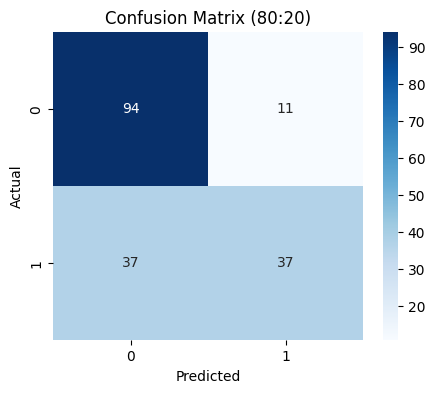

In [23]:
cm_80 = confusion_matrix(y_test_80, y_pred_80)

plt.figure(figsize=(5,4))
sns.heatmap(cm_80, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix (80:20)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

 18. 70:30 SPLIT

In [24]:
print("\n===== LOGISTIC REGRESSION (70:30) =====")

X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)


===== LOGISTIC REGRESSION (70:30) =====


 19. TRAIN MODEL (70:30)

In [25]:
model_70 = LogisticRegression(max_iter=3000)
model_70.fit(X_train_70, y_train_70)

LogisticRegression(max_iter=3000)

20. PREDICT (70:30)

In [26]:
y_pred_70 = model_70.predict(X_test_70)

21. ACCURACY (70:30)

In [27]:
train_acc_70 = model_70.score(X_train_70, y_train_70)
test_acc_70 = accuracy_score(y_test_70, y_pred_70)

print("Training Accuracy (70:30):", train_acc_70)
print("Testing Accuracy (70:30):", test_acc_70)


Training Accuracy (70:30): 0.6982343499197432
Testing Accuracy (70:30): 0.7201492537313433


 22. CLASSIFICATION REPORT (70:30)

In [28]:
print("\nClassification Report (70:30):\n")
print(classification_report(y_test_70, y_pred_70))



Classification Report (70:30):

              precision    recall  f1-score   support

           0       0.70      0.90      0.79       157
           1       0.76      0.47      0.58       111

    accuracy                           0.72       268
   macro avg       0.73      0.68      0.69       268
weighted avg       0.73      0.72      0.70       268



23. CONFUSION MATRIX (70:30)

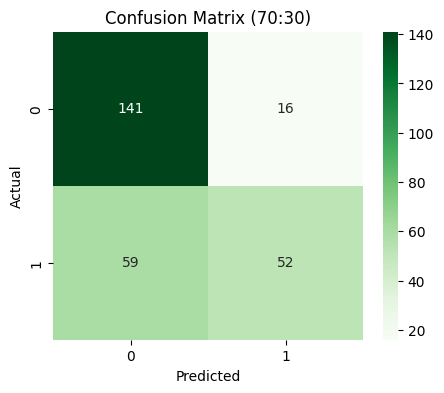

In [29]:
cm_70 = confusion_matrix(y_test_70, y_pred_70)

plt.figure(figsize=(5,4))
sns.heatmap(cm_70, annot=True, fmt='d', cmap="Greens")
plt.title("Confusion Matrix (70:30)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

24. COMPARISON TABLE

In [30]:
print("\n===== FINAL COMPARISON TABLE =====")

results = pd.DataFrame({
    "Split": ["80:20", "70:30"],
    "Training Accuracy": [train_acc_80, train_acc_70],
    "Testing Accuracy": [test_acc_80, test_acc_70]
})
print(results)


===== FINAL COMPARISON TABLE =====
   Split  Training Accuracy  Testing Accuracy
0  80:20           0.689607          0.731844
1  70:30           0.698234          0.720149


25. FEATURE IMPORTANCE

In [32]:
coef = pd.DataFrame(model_80.coef_, columns=X_processed.columns)
print("\nFeature Importance:\n", coef)


Feature Importance:
      Pclass      Age     SibSp     Parch     Fare
0 -0.702835 -0.41803 -0.268995  0.177613  0.22002


26. SAMPLE PREDICTION

In [33]:
sample = X_scaled[0].reshape(1, -1)
prediction = model_80.predict(sample)

print("\nSample Prediction:", prediction)


Sample Prediction: [0]


27. FINAL MESSAGE

In [34]:
print("\n===== MODEL COMPLETED SUCCESSFULLY ✅ =====")


===== MODEL COMPLETED SUCCESSFULLY ✅ =====
